# Health Index Orchestration Pipeline

Production-ready orchestration notebook for component-based Health Index computation using LSTM autoencoders.

**Architecture:**
- `LSTMAutoencoderPreprocessor`: Data cleaning, scaling, encoding, windowing
- `LSTMAutoencoderService`: Model training, inference, artifact persistence
- `HealthIndexService`: Reconstruction error scoring and Health Index computation

**Execution:**
Driven by `full_mapping.json` for component-specific signal selection and multi-model orchestration.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import tensorflow as tf
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# Add parent directory to path for src imports
import sys

# Get the project root (parent of notebooks directory)
# When running from notebooks folder, go up one level
current_dir = Path.cwd()
if current_dir.name == 'notebooks':
    project_root = current_dir.parent
else:
    # If running from project root, use current directory
    project_root = current_dir

# Add to path if not already there
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Current directory: {current_dir}")
print(f"Project root: {project_root}")
print(f"Python path includes project root: {str(project_root) in sys.path}")

# Now we can import from src with absolute imports
from src.services.preprocessing_service import LSTMAutoencoderPreprocessor, WindowingConfig
from src.services.model_service import LSTMAutoencoderService, LSTMAEModelConfig
from src.services.health_index_service import HealthIndexService, HealthIndexConfig

print("✓ Service imports successful")

Current directory: c:\Users\patri\Coddi\Proyectos\telemetry_dashboard\notebooks
Project root: c:\Users\patri\Coddi\Proyectos\telemetry_dashboard
Python path includes project root: True
✓ Service imports successful


In [2]:
# Optional utility imports (notebook implements its own logic, these are just conveniences)
try:
    from src.utils.logger import logger, get_logger
    print("✓ Logger imported from src.utils")
except ImportError:
    # Fallback: simple logger
    import logging
    logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
    logger = logging.getLogger('health_index')
    print("✓ Using fallback logger")

# Note: We don't need data_loader or data_cleaner imports
# The notebook implements its own data loading and cleaning logic below

✓ Logger imported from src.utils


## GPU Configuration

In [3]:
# Configure GPU
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU memory growth enabled for {len(gpus)} GPU(s)")
        
        from tensorflow.keras import mixed_precision
        policy = mixed_precision.Policy('mixed_float16')
        mixed_precision.set_global_policy(policy)
        print(f"✓ Mixed precision enabled: {policy.name}")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("⚠ No GPU detected - training will use CPU")

TensorFlow version: 2.21.0
2026-03-24 13:09:40,363 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
GPU Available: []
⚠ No GPU detected - training will use CPU


## Path Configuration

In [4]:
# Configuration
CLIENT = "cda"
EXECUTION_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# Paths
MAPPING_PATH = Path(f"../data/telemetry/silver/{CLIENT}/full_mapping.json")
INPUT_DATA_PATH = Path(f"../data/telemetry/silver/{CLIENT}/Telemetry_Wide_With_States")
PROCESSED_DATA_PATH = Path(f"../data/telemetry/silver/{CLIENT}/processed_data.parquet")
RECONSTRUCTIONS_DIR = Path(f"../data/telemetry/golden/{CLIENT}/reconstructions")
HEALTH_INDEX_PATH = Path(f"../data/telemetry/golden/{CLIENT}/health_index.parquet")

def get_model_artifacts_path(client: str, truck_model: str, component: str) -> Path:
    """Get model artifacts path for a specific component."""
    return Path(f"../models/{client}/{truck_model}/{component}")

def get_health_index_artifacts_path(client: str, truck_model: str, component: str) -> Path:
    """Get Health Index artifacts path for a specific component."""
    return Path(f"../models/{client}/{truck_model}/{component}/health_index")

def get_reconstructions_path(client: str, truck_model: str, component: str) -> Path:
    """Get reconstructions path for a specific component."""
    return RECONSTRUCTIONS_DIR / f"{truck_model}_{component}.parquet"

# Create base directories
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
RECONSTRUCTIONS_DIR.mkdir(parents=True, exist_ok=True)
HEALTH_INDEX_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f"✓ Execution timestamp: {EXECUTION_TIMESTAMP}")
print(f"✓ Client: {CLIENT}")
print(f"✓ Paths configured")

✓ Execution timestamp: 20260324_130940
✓ Client: cda
✓ Paths configured


## Load Mapping Configuration

In [5]:
# Load mapping
with open(MAPPING_PATH, 'r') as f:
    mapping = json.load(f)

id_to_truck_model = mapping['id_to_truck_model']
model_components = mapping['model_components']

print(f"✓ Loaded mapping for {len(id_to_truck_model)} units")
print(f"✓ Truck models: {set(id_to_truck_model.values())}")
print(f"✓ Components available: {list(next(iter(model_components.values())).keys())}")

# Display mapping structure
for truck_model, components in model_components.items():
    print(f"\n{truck_model}:")
    for component_name, component_info in components.items():
        print(f"  - {component_name}: {len(component_info['signals'])} signals, criticality={component_info['criticality']}")

✓ Loaded mapping for 11 units
✓ Truck models: {'CAT 789D', 'CAT 789C'}
✓ Components available: ['Motor', 'Tren de fuerza', 'Frenos', 'Direccion']

CAT 789C:
  - Motor: 6 signals, criticality=High
  - Tren de fuerza: 4 signals, criticality=High
  - Frenos: 4 signals, criticality=Medium
  - Direccion: 1 signals, criticality=Medium

CAT 789D:
  - Motor: 5 signals, criticality=High
  - Tren de fuerza: 4 signals, criticality=High
  - Frenos: 4 signals, criticality=Medium
  - Direccion: 1 signals, criticality=Medium


## Data Loading

In [6]:
# Load telemetry data
df = pd.read_parquet(INPUT_DATA_PATH)
df.sort_values(['Unit', 'Fecha'], inplace=True)
df.drop_duplicates(subset=['Unit', 'Fecha'], keep='first', inplace=True)

print(f"✓ Loaded {len(df):,} rows")
print(f"✓ Date range: {df['Fecha'].min()} to {df['Fecha'].max()}")
print(f"✓ Units: {df['Unit'].nunique()}")
print(f"✓ Columns: {df.columns.tolist()}")

df.head()

✓ Loaded 4,183,578 rows
✓ Date range: 2025-01-01 00:00:00 to 2026-01-31 00:00:00
✓ Units: 11
✓ Columns: ['Fecha', 'Unit', 'Estado', 'EstadoMaquina', 'EstadoCarga', 'GPSLat', 'GPSLon', 'GPSElevation', 'AirFltr', 'CnkcasePres', 'DiffLubePres', 'DiffTemp', 'EngCoolTemp', 'EngOilFltr', 'EngOilPres', 'EngSpd', 'GroundSpd', 'LtExhTemp', 'LtFBrkTemp', 'LtRBrkTemp', 'Payload', 'RAftrclrTemp', 'RtExhTemp', 'RtFBrkTemp', 'RtLtExhTemp', 'RtRBrkTemp', 'StrgOilTemp', 'TCOutTemp', 'TrnLubeTemp']


,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,AirFltr,CnkcasePres,...,LtRBrkTemp,Payload,RAftrclrTemp,RtExhTemp,RtFBrkTemp,RtLtExhTemp,RtRBrkTemp,StrgOilTemp,TCOutTemp,TrnLubeTemp
35727,2025-01-01 00:00:00,T_10,ND,ND,Sin Carga,-30.254047,-71.090775,998.516666,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56352,2025-01-01 00:01:00,T_10,ND,ND,Sin Carga,-30.254281,-71.091397,999.499998,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3902,2025-01-01 00:02:00,T_10,ND,ND,Sin Carga,-30.254324,-71.091386,998.488372,NaN,0.151770,...,78.0,0.0,35.366667,250.982564,80.00,-6.723517,78.833333,68.0,80.739394,86.555556
35780,2025-01-01 00:03:00,T_10,ND,ND,Sin Carga,-30.254331,-71.091389,996.500000,NaN,0.138828,...,78.0,0.0,35.275000,234.736923,79.75,-7.042637,78.875000,68.0,80.554545,86.416667
46245,2025-01-01 00:08:00,T_10,ND,ND,Sin Carga,-30.254323,-71.091415,1001.143333,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Check the amount of records per truck_model and component
for truck_model, components in model_components.items():
    sel_units = [unit for unit, model in id_to_truck_model.items() if model == truck_model]
    print(f"\n{truck_model}:")
    print(f'Units in this truck model are: {sel_units}')
    for component_name in components.keys():
        signals = components[component_name]['signals']
        count = df[df['Unit'].isin(sel_units)][signals].dropna().shape[0]
        print(f"  - {component_name}: {count} records with non-null signals")


CAT 789C:
Units in this truck model are: ['T_09', 'T_10', 'T_11', 'T_12', 'T_13', 'T_14', 'T_15', 'T_16', 'T_17']
  - Motor: 3101305 records with non-null signals
  - Tren de fuerza: 2081932 records with non-null signals
  - Frenos: 2860782 records with non-null signals
  - Direccion: 3125947 records with non-null signals

CAT 789D:
Units in this truck model are: ['T_18', 'T_24']
  - Motor: 650189 records with non-null signals
  - Tren de fuerza: 654415 records with non-null signals
  - Frenos: 659564 records with non-null signals
  - Direccion: 613940 records with non-null signals


## Data Cleaning and Reindexing

In [8]:
# Define outlier margins
margins = {
    # General
    'GPSLat': (-30.4, -30.1),
    'GPSLon': (-71.3, -70.9),
    'GPSElevation': (400, 2000),
    'GroundSpd': (0, 80),
    'EngSpd': (0, 2500),
    # Engine
    "EngCoolTemp": (30, 120),
    "RAftrclrTemp": (10, 100),
    "EngOilPres": (150, 700),
    "CnkcasePres": (-1.5, 1.5),
    "RtLtExhTemp": (-10, 10),
    "RtExhTemp": (150, 750),
    "LtExhTemp": (150, 750),
    # Transmission
    "DiffLubePres": (0, 800),
    "DiffTemp": (0, 150),
    "TrnLubeTemp": (-5, 120),
    "TCOutTemp": (30, 180),
    # Brakes
    "RtRBrkTemp": (20, 200),
    "RtFBrkTemp": (20, 200),
    "LtRBrkTemp": (20, 200),
    "LtFBrkTemp": (20, 200),
    # Direction
    'StrgOilTemp': (-10, 150),
}

def clean_data(df_in, margins):
    """Replace out-of-range values with NaN."""
    df = df_in.copy()
    for col, (lower, upper) in margins.items():
        if col in df.columns:
            df[col] = df[col].where((df[col] >= lower) & (df[col] <= upper), other=pd.NA)
    return df

# Clean data
df_cleaned = clean_data(df, margins)

# Drop unnecessary columns
columns_to_drop = ['Payload', 'EngOilFltr', 'AirFltr']
df_cleaned.drop(columns=[c for c in columns_to_drop if c in df_cleaned.columns], inplace=True)

# Get numeric columns for threshold filtering
num_cols = [col for col in margins.keys() if col in df_cleaned.columns]

# Drop rows with too many missing signals
df_cleaned.dropna(subset=num_cols, thresh=int(len(num_cols)/2), inplace=True)

# Fill categorical columns
categorical_cols = ['EstadoMaquina', 'EstadoCarga']
for col in categorical_cols:
    if col in df_cleaned.columns:
        df_cleaned[col].fillna('ND' if col == 'EstadoMaquina' else 'Sin Carga', inplace=True)

df_cleaned.reset_index(drop=True, inplace=True)

print(f"✓ After cleaning: {len(df_cleaned):,} rows ({len(df_cleaned)/len(df)*100:.1f}% retained)")
print(f"✓ Missing data per column:")
print(df_cleaned[num_cols].isna().sum().sort_values(ascending=False))

C:\Users\patri\AppData\Local\Temp\ipykernel_8068\3330033463.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna('ND' if col == 'EstadoMaquina' else 'Sin Carga', inplace=True)


✓ After cleaning: 4,129,184 rows (98.7% retained)
✓ Missing data per column:
RtLtExhTemp     1302333
DiffLubePres    1096269
RAftrclrTemp     665395
RtFBrkTemp       309884
RtExhTemp        168403
LtExhTemp        142551
TrnLubeTemp       78410
GPSLat            64828
GPSLon            64827
TCOutTemp         54782
GPSElevation      52156
StrgOilTemp       49185
DiffTemp          46612
EngOilPres        31987
LtRBrkTemp        24796
CnkcasePres       16484
LtFBrkTemp        12376
RtRBrkTemp        11330
EngCoolTemp       10824
GroundSpd          3834
EngSpd                6
dtype: int64


In [9]:
# Reindex and interpolate per unit
from tqdm.auto import tqdm

UNIT_COL = "Unit"
TIME_COL = "Fecha"
CAT_COLS = ["EstadoMaquina", "EstadoCarga"]
FREQ = "1min"
INTERP_LIMIT = 10

def reindex_and_interpolate_unit(
    unit_df: pd.DataFrame,
    num_cols: List[str],
    freq: str = FREQ,
    interp_limit: int = INTERP_LIMIT
) -> pd.DataFrame:
    """Reindex to 1-minute frequency and interpolate gaps."""
    out = unit_df.copy().sort_values(TIME_COL).reset_index(drop=True)
    
    if out.empty:
        return out.copy()
    
    original_timestamps = set(out[TIME_COL])
    
    # Create full time index
    full_time_index = pd.date_range(
        start=out[TIME_COL].min(),
        end=out[TIME_COL].max(),
        freq=freq
    )
    
    out = out.set_index(TIME_COL).reindex(full_time_index)
    out.index.name = TIME_COL
    
    # Reconstruct metadata
    out[UNIT_COL] = unit_df[UNIT_COL].iloc[0]
    
    # Forward/backward fill categorical
    for c in CAT_COLS:
        if c in unit_df.columns:
            out[c] = out[c].ffill().bfill()
    
    valid_cols = [c for c in num_cols if c in out.columns]
    
    # Track what was missing before interpolation
    before_na = out[valid_cols].isna()
    
    # Flag reindexed rows
    out["created_by_reindex"] = (~out.index.isin(original_timestamps)).astype("int8")
    
    # Interpolate numeric columns (time-based, limited to INTERP_LIMIT consecutive points)
    out[valid_cols] = out[valid_cols].interpolate(
        method="time",
        limit=interp_limit,
        limit_area="inside"
    )
    
    # Track imputation
    out["imputed_any"] = (before_na & ~out[valid_cols].isna()).any(axis=1).astype("int8")
    out["n_imputed_signals"] = (before_na & ~out[valid_cols].isna()).sum(axis=1).astype("int16")
    
    # Time gap tracking
    out["time_gap_min"] = (
        pd.Series(out.index, index=out.index).diff().dt.total_seconds().div(60)
    )
    
    return out.reset_index()

# Apply per unit
unit_results = []
for unit_id, unit_df in tqdm(df_cleaned.groupby(UNIT_COL, sort=False), desc="Reindexing units"):
    unit_out = reindex_and_interpolate_unit(unit_df, num_cols)
    unit_results.append(unit_out)

processed_df = pd.concat(unit_results, ignore_index=True) if unit_results else df_cleaned.head(0).copy()

print(f"\n✓ After reindexing: {len(processed_df):,} rows")
print(f"✓ Created by reindex: {processed_df['created_by_reindex'].sum():,} rows")
print(f"✓ Rows with imputation: {processed_df['imputed_any'].sum():,}")

# Save processed data
processed_df.to_parquet(PROCESSED_DATA_PATH, index=False)
print(f"✓ Saved processed data to {PROCESSED_DATA_PATH}")

processed_df.head()

Reindexing units:   0%|          | 0/11 [00:00<?, ?it/s]


✓ After reindexing: 6,181,650 rows
✓ Created by reindex: 2,052,466 rows
✓ Rows with imputation: 1,713,970
✓ Saved processed data to ..\data\telemetry\silver\cda\processed_data.parquet


,Fecha,Unit,Estado,EstadoMaquina,EstadoCarga,GPSLat,GPSLon,GPSElevation,CnkcasePres,DiffLubePres,...,RtFBrkTemp,RtLtExhTemp,RtRBrkTemp,StrgOilTemp,TCOutTemp,TrnLubeTemp,created_by_reindex,imputed_any,n_imputed_signals,time_gap_min
0,2025-01-01 00:02:00,T_10,ND,ND,Sin Carga,-30.254324,-71.091386,998.488372,0.151770,NaN,...,80.000000,-6.723517,78.833333,68.000000,80.739394,86.555556,0,0,0,NaN
1,2025-01-01 00:03:00,T_10,ND,ND,Sin Carga,-30.254331,-71.091389,996.500000,0.138828,NaN,...,79.750000,-7.042637,78.875000,68.000000,80.554545,86.416667,0,0,0,1.0
2,2025-01-01 00:04:00,T_10,NaN,ND,Sin Carga,-30.254292,-71.091454,997.133591,0.111046,NaN,...,79.333333,-6.907596,78.559524,67.309524,80.566722,86.045139,1,1,20,1.0
3,2025-01-01 00:05:00,T_10,NaN,ND,Sin Carga,-30.254252,-71.091520,997.767182,0.083264,NaN,...,78.916667,-6.772554,78.244048,66.619048,80.578899,85.673611,1,1,20,1.0
4,2025-01-01 00:06:00,T_10,NaN,ND,Sin Carga,-30.254213,-71.091585,998.400773,0.055482,NaN,...,78.500000,-6.637512,77.928571,65.928571,80.591076,85.302083,1,1,20,1.0


## Service Configuration

In [10]:
WINDOW_SIZE = 60  # minutes

def create_windowing_config(
    signal_cols: List[str],
    window_size: int = WINDOW_SIZE,
    min_numeric_coverage: float = 0.92,
    min_row_coverage: float = 0.92,
    max_created_fraction: float = 0.08,
    max_imputed_fraction: float = 0.08
) -> WindowingConfig:
    """Create windowing configuration for preprocessing."""
    return WindowingConfig(
        unit_col=UNIT_COL,
        time_col=TIME_COL,
        numeric_cols=signal_cols,
        categorical_cols=CAT_COLS,
        train_window_size=window_size,
        train_step_size=1,
        predict_window_size=window_size,
        min_numeric_coverage=min_numeric_coverage,
        min_row_coverage=min_row_coverage,
        max_created_fraction=max_created_fraction,
        max_imputed_fraction=max_imputed_fraction,
        train_fill_value=0.0,
        predict_fill_value=-10.0,
    )

def create_model_config(
    latent_dim: int = 8,
    encoder_lstm_1: int = 32,
    encoder_lstm_2: int = 16,
    decoder_lstm_1: int = 16,
    decoder_lstm_2: int = 32,
    dropout_rate: float = 0.2,
    learning_rate: float = 1e-3,
    batch_size: int = 32,
    epochs: int = 50,
    validation_split: float = 0.2,
    early_stopping_patience: int = 5
) -> LSTMAEModelConfig:
    """Create model configuration."""
    return LSTMAEModelConfig(
        latent_dim=latent_dim,
        encoder_lstm_1=encoder_lstm_1,
        encoder_lstm_2=encoder_lstm_2,
        decoder_lstm_1=decoder_lstm_1,
        decoder_lstm_2=decoder_lstm_2,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=validation_split,
        early_stopping_patience=early_stopping_patience,
    )

def create_health_index_config(
    alpha: float = 1.0,
    time_agg: str = "mean",
    signal_agg: str = "rms",
    unit_agg: str = "mean",
    percentile_low: int = 50,
    percentile_high: int = 95
) -> HealthIndexConfig:
    """Create Health Index configuration."""
    return HealthIndexConfig(
        alpha=alpha,
        time_agg=time_agg,
        signal_agg=signal_agg,
        unit_agg=unit_agg,
        percentile_low=percentile_low,
        percentile_high=percentile_high,
    )

print("✓ Configuration factory functions defined")

✓ Configuration factory functions defined


## Hyperparameter Optimization with Optuna

In [11]:
def optimize_hyperparameters(
    df_train: pd.DataFrame,
    signal_cols: List[str],
    component: str,
    truck_model: str,
    n_trials: int = 50,
    timeout: Optional[int] = None,
    window_size: int = WINDOW_SIZE
) -> Tuple[Dict, optuna.Study]:
    """
    Optimize hyperparameters using Optuna.
    
    Returns:
        best_params: Dictionary of best parameters
        study: Optuna study object with all trial history
    """
    
    def objective(trial):
        # Suggest hyperparameters
        latent_dim = trial.suggest_int('latent_dim', 32, 64, step=8)
        encoder_lstm_1 = trial.suggest_int('encoder_lstm_1', 8, 256, step=8)
        encoder_lstm_2 = trial.suggest_int('encoder_lstm_2', 8, 128, step=8)
        decoder_lstm_1 = encoder_lstm_2  # Mirror encoder
        decoder_lstm_2 = encoder_lstm_1
        dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.4)
        learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
        batch_size = trial.suggest_int('batch_size', 32, 256, step=32)
        
        # Create configs
        windowing_config = create_windowing_config(signal_cols, window_size=window_size)
        model_config = create_model_config(
            latent_dim=latent_dim,
            encoder_lstm_1=encoder_lstm_1,
            encoder_lstm_2=encoder_lstm_2,
            decoder_lstm_1=decoder_lstm_1,
            decoder_lstm_2=decoder_lstm_2,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate,
            batch_size=batch_size,
            epochs=30,  # Reduced for optimization
            early_stopping_patience=3
        )
        
        # Create preprocessor and service
        preprocessor = LSTMAutoencoderPreprocessor(windowing_config)
        service = LSTMAutoencoderService(preprocessor, model_config)
        
        try:
            # Train
            train_result = service.fit(df_train, verbose=1)
            
            # Get final validation loss
            val_loss = train_result['history']['val_loss'][-1]
            
            return val_loss
        
        except Exception as e:
            print(f"Trial failed: {e}")
            return float('inf')
    
    # Create study
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=42),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
        study_name=f"{truck_model}_{component}_optimization"
    )
    
    # Optimize
    study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=False)
    
    print(f"\n✓ Optimization complete")
    print(f"  Best trial: {study.best_trial.number}")
    print(f"  Best val_loss: {study.best_value:.6f}")
    print(f"  Best params: {study.best_params}")
    
    return study.best_params, study

print("✓ Optuna optimization function defined")

✓ Optuna optimization function defined


## Training Pipeline

In [12]:
def train_component_model(
    df_train: pd.DataFrame,
    signal_cols: List[str],
    component: str,
    best_params: Dict,
    artifacts_dir: Path
) -> LSTMAutoencoderService:
    """Train a component-specific model with best parameters."""
    
    # Create configs from best params
    windowing_config = create_windowing_config(
        signal_cols,
        window_size=WINDOW_SIZE
    )
    
    model_config = create_model_config(
        latent_dim=best_params.get('latent_dim', 8),
        encoder_lstm_1=best_params.get('encoder_lstm_1', 32),
        encoder_lstm_2=best_params.get('encoder_lstm_2', 16),
        decoder_lstm_1=best_params.get('decoder_lstm_1', 16),
        decoder_lstm_2=best_params.get('decoder_lstm_2', 32),
        dropout_rate=best_params.get('dropout_rate', 0.2),
        learning_rate=best_params.get('learning_rate', 1e-3),
        batch_size=best_params.get('batch_size', 32),
        epochs=50,  # Full training
        validation_split=0.2,
        early_stopping_patience=5
    )
    
    # Create service
    preprocessor = LSTMAutoencoderPreprocessor(windowing_config)
    service = LSTMAutoencoderService(preprocessor, model_config)
    
    # Train
    print(f"\nTraining {component} model...")
    train_result = service.fit(df_train, verbose=1)
    
    # Save artifacts
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    service.save(str(artifacts_dir))
    
    # Save training metadata
    metadata = {
        'component': component,
        'signals': signal_cols,
        'execution_timestamp': EXECUTION_TIMESTAMP,
        'n_train_windows': train_result['n_train_windows'],
        'best_params': best_params,
        'final_train_loss': train_result['history']['loss'][-1],
        'final_val_loss': train_result['history']['val_loss'][-1],
    }
    
    with open(artifacts_dir / 'training_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"✓ Model saved to {artifacts_dir}")
    
    return service

print("✓ Training pipeline function defined")

✓ Training pipeline function defined


## Full-Data Inference and Reconstruction Persistence

In [13]:
def run_full_inference_and_save_reconstructions(
    service: LSTMAutoencoderService,
    df_full: pd.DataFrame,
    component: str,
    truck_model: str,
    save_path: Path
) -> Tuple[Path, Dict]:
    """
    Run inference on full dataset and persist timestamp-level reconstructions.
    Predictions are inverse-transformed to original scale before saving.
    
    Returns:
        save_path: Path where reconstructions were saved
        pred_result: Raw prediction result dictionary
    """
    print(f"\nRunning inference for {component} on full dataset...")
    
    # Get predictions (these are scaled)
    pred_result = service.predict_windows(df_full, return_reconstruction=True)
    
    # Extract window metadata
    pred_meta = pred_result['pred_meta']
    y_pred_scaled = pred_result['y_pred']
    y_true_scaled = pred_result['y_true']
    
    # Get signal names
    signal_names = service.preprocessor.target_feature_names_
    
    # Inverse transform to original scale
    print(f"Inverse transforming predictions to original scale...")
    n_windows, window_size, n_signals = y_pred_scaled.shape
    
    # Reshape for inverse transform: (n_windows * window_size, n_signals)
    y_pred_reshaped = y_pred_scaled.reshape(-1, n_signals)
    y_true_reshaped = y_true_scaled.reshape(-1, n_signals)
    
    # Inverse transform using the scaler
    y_pred_original = service.preprocessor.numeric_scaler.inverse_transform(y_pred_reshaped)
    y_true_original = service.preprocessor.numeric_scaler.inverse_transform(y_true_reshaped)
    
    # Reshape back to (n_windows, window_size, n_signals)
    y_pred_original = y_pred_original.reshape(n_windows, window_size, n_signals)
    y_true_original = y_true_original.reshape(n_windows, window_size, n_signals)
    
    # Expand windows to timestamp level
    reconstruction_rows = []
    
    for window_idx in range(len(pred_meta)):
        meta = pred_meta.iloc[window_idx]
        unit = meta['Unit']
        start_time = meta['start_time']
        
        # Generate timestamps for this window
        timestamps = pd.date_range(start=start_time, periods=window_size, freq='1min')
        
        for t_idx, timestamp in enumerate(timestamps):
            row = {
                'Unit': unit,
                'Fecha': timestamp,
                'component': component,
                'truck_model': truck_model,
                'window_idx': window_idx,
                'time_idx_in_window': t_idx
            }
            
            # Add actual values (now in original scale)
            for sig_idx, sig_name in enumerate(signal_names):
                actual_val = float(y_true_original[window_idx, t_idx, sig_idx])
                predicted_val = float(y_pred_original[window_idx, t_idx, sig_idx])
                
                row[f'{sig_name}_actual'] = actual_val
                row[f'{sig_name}_predicted'] = predicted_val
                row[f'{sig_name}_error'] = abs(actual_val - predicted_val)
            
            reconstruction_rows.append(row)
    
    reconstructions_df = pd.DataFrame(reconstruction_rows)
    
    # Save to parquet
    save_path.parent.mkdir(parents=True, exist_ok=True)
    reconstructions_df.to_parquet(save_path, index=False)
    
    print(f"✓ Generated {len(reconstructions_df):,} reconstruction rows")
    print(f"✓ Saved reconstructions to {save_path}")
    
    return save_path, pred_result

print("✓ Inference and reconstruction function defined")

✓ Inference and reconstruction function defined


## Health Index Computation and Persistence

In [14]:
def compute_and_save_health_index(
    service: LSTMAutoencoderService,
    pred_result: Dict,
    component: str,
    truck_model: str,
    hi_artifacts_dir: Path
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Compute Health Index from reconstruction errors and save artifacts.
    
    Returns:
        signal_window_df: Per-signal per-window errors
        window_hi_df: Per-window Health Index
        unit_hi_df: Per-unit aggregated Health Index
    """
    print(f"\nComputing Health Index for {component}...")
    
    # Create Health Index service
    hi_config = create_health_index_config()
    hi_service = HealthIndexService(
        signal_cols=service.preprocessor.target_feature_names_,
        config=hi_config
    )
    
    # Fit error statistics from training data (using validation as reference)
    hi_service.fit_error_stats(
        y_true=pred_result['y_true'],
        y_pred=pred_result['y_pred']
    )
    
    # Save Health Index artifacts
    hi_artifacts_dir.mkdir(parents=True, exist_ok=True)
    hi_service.save(str(hi_artifacts_dir))
    
    # Score windows
    signal_window_df, window_hi_df, unit_hi_df = hi_service.score_windows(
        y_true=pred_result['y_true'],
        y_pred=pred_result['y_pred'],
        pred_meta=pred_result['pred_meta']
    )
    
    # Add metadata
    for df in [signal_window_df, window_hi_df, unit_hi_df]:
        df['component'] = component
        df['truck_model'] = truck_model
        df['execution_timestamp'] = EXECUTION_TIMESTAMP
    
    print(f"✓ Health Index computed")
    print(f"  - {len(window_hi_df)} windows scored")
    print(f"  - {len(unit_hi_df)} units scored")
    print(f"  - Mean Health Index: {window_hi_df['health_index'].mean():.4f}")
    
    return signal_window_df, window_hi_df, unit_hi_df

print("✓ Health Index computation function defined")

✓ Health Index computation function defined


## Component-Based Orchestration

In [15]:
def process_component(
    component_name: str,
    component_info: Dict,
    truck_model: str,
    df_full: pd.DataFrame,
    df_train: pd.DataFrame,
    run_optimization: bool = True,
    n_trials: int = 20
) -> Tuple[Path, pd.DataFrame]:
    """
    Complete pipeline for a single component:
    1. Optionally run Optuna optimization
    2. Train model with best parameters
    3. Run full-data inference
    4. Save reconstructions
    5. Compute and save Health Index
    
    Returns:
        reconstructions_path: Path to saved reconstructions
        window_hi_df: Window-level Health Index
    """
    signal_cols = component_info['signals']
    criticality = component_info['criticality']
    
    print(f"\n{'='*80}")
    print(f"PROCESSING COMPONENT: {component_name}")
    print(f"Truck Model: {truck_model}")
    print(f"Signals: {signal_cols}")
    print(f"Criticality: {criticality}")
    print(f"{'='*80}")
    
    # Define artifacts paths
    artifacts_dir = get_model_artifacts_path(CLIENT, truck_model, component_name)
    hi_artifacts_dir = get_health_index_artifacts_path(CLIENT, truck_model, component_name)
    optuna_dir = artifacts_dir / "optuna"
    optuna_dir.mkdir(parents=True, exist_ok=True)
    
    # Step 1: Optimization (optional)
    if run_optimization:
        print(f"\n[1/5] Running Optuna optimization...")
        best_params, study = optimize_hyperparameters(
            df_train, signal_cols, component_name, truck_model, n_trials=n_trials
        )
        
        # Save Optuna results
        optuna_results = {
            'best_params': best_params,
            'best_value': study.best_value,
            'best_trial_number': study.best_trial.number,
            'n_trials': len(study.trials),
            'execution_timestamp': EXECUTION_TIMESTAMP,
            'component': component_name,
            'truck_model': truck_model
        }
        
        # Save trials history
        trials_data = []
        for trial in study.trials:
            trials_data.append({
                'number': trial.number,
                'value': trial.value,
                'params': trial.params,
                'state': trial.state.name
            })
        optuna_results['trials'] = trials_data
        
        with open(optuna_dir / f"optuna_results_{EXECUTION_TIMESTAMP}.json", 'w') as f:
            json.dump(optuna_results, f, indent=2)
        
        print(f"✓ Optuna results saved to {optuna_dir}")
    else:
        # Use default parameters
        best_params = {
            'latent_dim': 8,
            'encoder_lstm_1': 32,
            'encoder_lstm_2': 16,
            'decoder_lstm_1': 16,
            'decoder_lstm_2': 32,
            'dropout_rate': 0.2,
            'learning_rate': 1e-3,
            'batch_size': 32
        }
        print(f"\n[1/5] Using default parameters (optimization skipped)")
    
    # Step 2: Train model
    print(f"\n[2/5] Training model...")
    service = train_component_model(
        df_train, signal_cols, component_name, best_params, artifacts_dir
    )
    
    # Step 3: Full-data inference
    print(f"\n[3/5] Running full-data inference...")
    reconstructions_path = get_reconstructions_path(CLIENT, truck_model, component_name)
    saved_recon_path, pred_result = run_full_inference_and_save_reconstructions(
        service, df_full, component_name, truck_model, reconstructions_path
    )
    
    # Step 4: Compute Health Index
    print(f"\n[4/5] Computing Health Index...")
    signal_window_df, window_hi_df, unit_hi_df = compute_and_save_health_index(
        service, pred_result, component_name, truck_model, hi_artifacts_dir
    )
    
    # Step 5: Consolidate outputs
    print(f"\n[5/5] Consolidating outputs...")
    
    # Compact Health Index table (required columns only)
    compact_hi_df = window_hi_df[[
        'Unit', 'start_time', 'end_time', 'health_index',
        'reconstruction_error_score', 'component', 'truck_model',
        'created_fraction', 'imputed_fraction'
    ]].copy()
    
    print(f"\n✓ Component {component_name} processing complete")
    print(f"  - Reconstructions saved to: {saved_recon_path}")
    print(f"  - Health Index windows: {len(compact_hi_df):,} rows")
    
    return saved_recon_path, compact_hi_df

print("✓ Component orchestration function defined")

✓ Component orchestration function defined


## Execution Example

This example demonstrates the full pipeline for all components driven by the mapping file.

In [16]:
# Prepare train/test split
WEEKS_FOR_TEST = 12
split_date = processed_df['Fecha'].max() - pd.Timedelta(weeks=WEEKS_FOR_TEST)

df_train = processed_df[processed_df['Fecha'] < split_date].copy()
df_full = processed_df.copy()  # Use full dataset for inference

print(f"Train data: {len(df_train):,} rows (up to {split_date})")
print(f"Full data: {len(df_full):,} rows")

Train data: 4,884,644 rows (up to 2025-11-08 00:00:00)
Full data: 6,181,650 rows


In [17]:
# Process all components for all truck models
all_reconstruction_paths = []
all_health_index = []

for truck_model, components in model_components.items():
    print(f"\n{'#'*80}")
    print(f"TRUCK MODEL: {truck_model}")
    print(f"{'#'*80}")
    
    # Get units for this truck model
    units_for_model = [unit for unit, model in id_to_truck_model.items() if model == truck_model]
    print(f"Units: {units_for_model}")
    
    # Filter data for this truck model
    df_train_model = df_train[df_train['Unit'].isin(units_for_model)].copy()
    df_full_model = df_full[df_full['Unit'].isin(units_for_model)].copy()
    
    for component_name, component_info in components.items():
        n_trials_component = 25 if component_info['criticality'] == 'High' else 10
        try:
            recon_path, hi_df = process_component(
                component_name=component_name,
                component_info=component_info,
                truck_model=truck_model,
                df_full=df_full_model,
                df_train=df_train_model,
                run_optimization=True,  # Set to False to skip optimization
                n_trials=n_trials_component  # Adjust based on available time/resources
            )
            
            all_reconstruction_paths.append(recon_path)
            all_health_index.append(hi_df)
            
        except Exception as e:
            print(f"\n✗ Failed to process {truck_model} - {component_name}: {e}")
            import traceback
            traceback.print_exc()
            continue

print(f"\n{'='*80}")
print("PIPELINE COMPLETE")
print(f"{'='*80}")


################################################################################
TRUCK MODEL: CAT 789C
################################################################################
Units: ['T_09', 'T_10', 'T_11', 'T_12', 'T_13', 'T_14', 'T_15', 'T_16', 'T_17']


[I 2026-03-24 13:10:52,837] A new study created in memory with name: CAT 789C_Motor_optimization



PROCESSING COMPONENT: Motor
Truck Model: CAT 789C
Signals: ['EngCoolTemp', 'RAftrclrTemp', 'EngOilPres', 'CnkcasePres', 'RtExhTemp', 'LtExhTemp']
Criticality: High

[1/5] Running Optuna optimization...
Epoch 1/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 120s 381ms/step - loss: 0.8994 - val_loss: 1.1434
Epoch 2/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 107s 352ms/step - loss: 0.7446 - val_loss: 0.9909
Epoch 3/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 109s 361ms/step - loss: 0.6338 - val_loss: 0.8095
Epoch 4/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 112s 371ms/step - loss: 0.4636 - val_loss: 0.6825
Epoch 5/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 109s 360ms/step - loss: 0.3973 - val_loss: 0.6271
Epoch 6/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 111s 367ms/step - loss: 0.3536 - val_loss: 0.5880
Epoch 7/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 110s 362ms/step - loss: 0.3229 - val_loss: 0.5821
Epoch 8/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 108s 357ms/step - loss: 0.3014 - val_loss: 0.5533
Epoch 9/30
303/303 ━━━━━━━━━━━━━━━━━━━━ 104s 343ms/step - loss: 0.2861 - val_

[I 2026-03-24 13:55:28,162] Trial 0 finished with value: 0.37245747447013855 and parameters: {'latent_dim': 40, 'encoder_lstm_1': 248, 'encoder_lstm_2': 96, 'dropout_rate': 0.279597545259111, 'learning_rate': 2.9380279387035334e-05, 'batch_size': 64}. Best is trial 0 with value: 0.37245747447013855.


Epoch 1/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 80s 982ms/step - loss: 1.2878 - val_loss: 1.8717
Epoch 2/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 1.0593 - val_loss: 1.7476
Epoch 3/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 74s 972ms/step - loss: 0.9536 - val_loss: 1.6550
Epoch 4/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 74s 977ms/step - loss: 0.8906 - val_loss: 1.5606
Epoch 5/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 73s 967ms/step - loss: 0.8468 - val_loss: 1.4620
Epoch 6/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 69s 914ms/step - loss: 0.8238 - val_loss: 1.3683
Epoch 7/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 69s 903ms/step - loss: 0.8082 - val_loss: 1.3128
Epoch 8/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 70s 916ms/step - loss: 0.7961 - val_loss: 1.2709
Epoch 9/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 71s 938ms/step - loss: 0.7853 - val_loss: 1.2325
Epoch 10/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 70s 920ms/step - loss: 0.7751 - val_loss: 1.1997
Epoch 11/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 72s 945ms/step - loss: 0.7662 - val_loss: 1.1727
Epoch 12/30
76/76 ━━━━━━━━━━━━━━━━━━━━ 69s 9

...

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - loss: 13.3237 - val_loss: 7.5326
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - loss: 5.8583 - val_loss: 2.6422
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - loss: 4.1544 - val_loss: 3.9292
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 2.9727 - val_loss: 2.0359
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 2.1012 - val_loss: 1.8108
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - loss: 1.7188 - val_loss: 1.3243
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 1.3606 - val_loss: 1.1413
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - loss: 1.1864 - val_loss: 1.1011
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - loss: 1.0743 - val_loss: 0.9794
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 1.0018 - val_loss: 0.8741
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 0.9506 - val_loss: 0.8575
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - loss: 0.9106 - val_l

[I 2026-03-28 13:39:16,019] Trial 8 finished with value: 1.2639950513839722 and parameters: {'latent_dim': 48, 'encoder_lstm_1': 48, 'encoder_lstm_2': 128, 'dropout_rate': 0.3325398470083344, 'learning_rate': 0.006584106160121612, 'batch_size': 256}. Best is trial 4 with value: 0.8811128735542297.


Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - loss: 40.9072 - val_loss: 17.5931
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - loss: 22.8590 - val_loss: 13.5551
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 14.1114 - val_loss: 11.9961
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - loss: 11.3643 - val_loss: 10.7292
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 9.8916 - val_loss: 9.8700
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - loss: 8.9871 - val_loss: 9.0374
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 8.2363 - val_loss: 8.3131
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - loss: 7.6487 - val_loss: 7.6892
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - loss: 7.1350 - val_loss: 7.1831
Epoch 10/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - loss: 6.7220 - val_loss: 6.7162
Epoch 11/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - loss: 6.3305 - val_loss: 6.2671
Epoch 12/30
125/125 ━━━━━━━━━━━━━

[I 2026-03-28 14:57:54,632] Trial 9 finished with value: 3.0624396800994873 and parameters: {'latent_dim': 48, 'encoder_lstm_1': 240, 'encoder_lstm_2': 16, 'dropout_rate': 0.15879485872574356, 'learning_rate': 1.3667272915456215e-05, 'batch_size': 96}. Best is trial 4 with value: 0.8811128735542297.



✓ Optimization complete
  Best trial: 4
  Best val_loss: 0.881113
  Best params: {'latent_dim': 48, 'encoder_lstm_1': 208, 'encoder_lstm_2': 32, 'dropout_rate': 0.2542703315240835, 'learning_rate': 0.0005987474910461401, 'batch_size': 32}
✓ Optuna results saved to ..\models\cda\CAT 789D\Direccion\optuna

[2/5] Training model...

Training Direccion model...
Epoch 1/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 116s 287ms/step - loss: 10.5647 - val_loss: 5.2315
Epoch 2/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 105s 280ms/step - loss: 3.5132 - val_loss: 3.0043
Epoch 3/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 108s 288ms/step - loss: 2.5338 - val_loss: 2.1978
Epoch 4/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 103s 277ms/step - loss: 2.0303 - val_loss: 1.7414
Epoch 5/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 104s 277ms/step - loss: 1.6846 - val_loss: 1.5224
Epoch 6/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 102s 272ms/step - loss: 1.5314 - val_loss: 1.4821
Epoch 7/50
374/374 ━━━━━━━━━━━━━━━━━━━━ 102s 273ms/step - loss: 1.3252 - val_loss: 1.2474
Epoch 8/5

In [18]:
# Consolidate and save final outputs
if all_reconstruction_paths:
    print(f"✓ Saved {len(all_reconstruction_paths)} reconstruction files:")
    total_size_mb = 0
    for path in all_reconstruction_paths:
        # Get file size
        file_size_mb = path.stat().st_size / (1024 * 1024)
        total_size_mb += file_size_mb
        print(f"  - {path.name}: {file_size_mb:.2f} MB")
    print(f"\n  Total size: {total_size_mb:.2f} MB")
    print(f"  Reconstructions directory: {RECONSTRUCTIONS_DIR}")
else:
    print("⚠ No reconstructions to save")

if all_health_index:
    final_health_index = pd.concat(all_health_index, ignore_index=True)
    final_health_index.to_parquet(HEALTH_INDEX_PATH, index=False)
    print(f"\n✓ Saved {len(final_health_index):,} Health Index rows to {HEALTH_INDEX_PATH}")
    
    # Display summary statistics
    print(f"\nHealth Index Summary:")
    print(final_health_index.groupby(['truck_model', 'component'])['health_index'].agg(['count', 'mean', 'std', 'min', 'max']))
else:
    print("⚠ No Health Index results to save")

✓ Saved 8 reconstruction files:
  - CAT 789C_Motor.parquet: 398.91 MB
  - CAT 789C_Tren de fuerza.parquet: 271.91 MB
  - CAT 789C_Frenos.parquet: 244.54 MB
  - CAT 789C_Direccion.parquet: 81.73 MB
  - CAT 789D_Motor.parquet: 74.25 MB
  - CAT 789D_Tren de fuerza.parquet: 60.92 MB
  - CAT 789D_Frenos.parquet: 54.91 MB
  - CAT 789D_Direccion.parquet: 20.72 MB

  Total size: 1207.89 MB
  Reconstructions directory: ..\data\telemetry\golden\cda\reconstructions

✓ Saved 374,156 Health Index rows to ..\data\telemetry\golden\cda\health_index.parquet

Health Index Summary:
                            count      mean       std       min       max
truck_model component                                                    
CAT 789C    Direccion       74581  0.850853  0.199574  0.000005  1.000000
            Frenos          74581  0.811956  0.179646  0.000259  1.000000
            Motor           74581  0.782372  0.129162  0.166329  0.993717
            Tren de fuerza  74581  0.829766  0.177391  0.025

## Visualization and Analysis

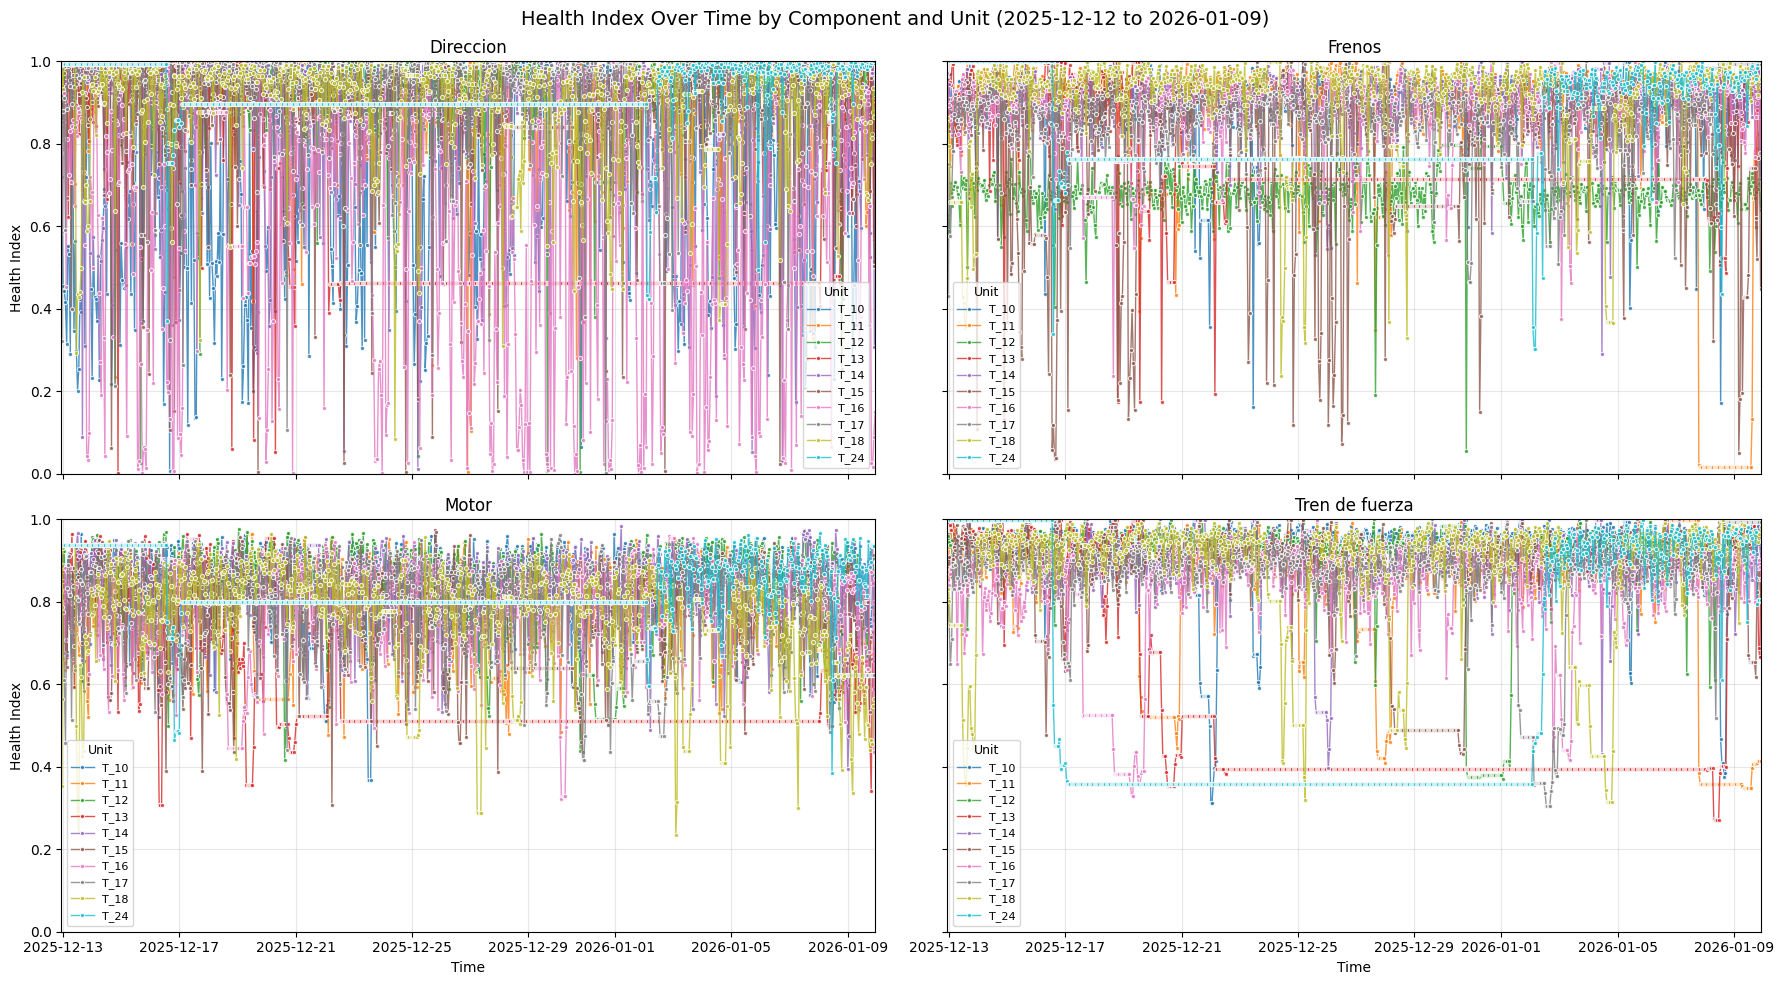

✓ Visualization complete


In [19]:
# Plot Health Index trends by component, with one subplot per component
if all_health_index and not final_health_index.empty:
    df_plot = final_health_index.copy()

    # Ensure datetime
    df_plot['start_time'] = pd.to_datetime(df_plot['start_time'])

    # 6-week rolling window based on latest timestamp in the data
    end_time = df_plot['start_time'].max() - pd.Timedelta(weeks=3)
    start_time = end_time - pd.Timedelta(weeks=4)

    df_plot = df_plot[
        (df_plot['start_time'] >= start_time) &
        (df_plot['start_time'] <= end_time)
    ].copy()

    # Sort for cleaner line plotting
    df_plot = df_plot.sort_values(['component', 'Unit', 'start_time'])

    components = sorted(df_plot['component'].dropna().unique())

    # In case there are more than 4 components, create one 2x2 figure at a time
    for i in range(0, len(components), 4):
        component_subset = components[i:i+4]

        fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)
        axes = axes.flatten()

        for ax, component in zip(axes, component_subset):
            component_data = df_plot[df_plot['component'] == component]

            sns.lineplot(
                data=component_data,
                x='start_time',
                y='health_index',
                hue='Unit',
                marker='o',
                markersize=3,
                linewidth=1,
                alpha=0.8,
                ax=ax
            )

            ax.set_title(component)
            ax.set_xlabel('Time')
            ax.set_ylabel('Health Index')
            ax.set_ylim(0, 1)
            ax.set_xlim(start_time, end_time)   # same x-axis in all subplots
            ax.grid(True, alpha=0.3)

            # Keep legend inside each subplot only if useful;
            # for many units this can get crowded.
            ax.legend(title='Unit', fontsize=8, title_fontsize=9)

        # Hide empty axes if fewer than 4 components in the last figure
        for j in range(len(component_subset), 4):
            axes[j].set_visible(False)

        fig.suptitle(
            f'Health Index Over Time by Component and Unit ({start_time.date()} to {end_time.date()})',
            fontsize=14
        )
        plt.tight_layout()
        plt.show()

    print("✓ Visualization complete")

else:
    print("⚠ No data available for visualization")

## Pipeline Summary

In [20]:
# Generate execution summary
summary = {
    'execution_timestamp': EXECUTION_TIMESTAMP,
    'client': CLIENT,
    'mapping': {
        'n_units': len(id_to_truck_model),
        'truck_models': list(set(id_to_truck_model.values())),
        'components_processed': []
    },
    'data': {
        'input_rows': len(df),
        'processed_rows': len(processed_df),
        'train_rows': len(df_train),
        'date_range': {
            'start': str(processed_df['Fecha'].min()),
            'end': str(processed_df['Fecha'].max())
        }
    },
    'outputs': {
        'reconstructions_files': len(all_reconstruction_paths),
        'reconstruction_paths': [str(p) for p in all_reconstruction_paths] if all_reconstruction_paths else [],
        'health_index_rows': len(final_health_index) if all_health_index else 0,
        'reconstructions_dir': str(RECONSTRUCTIONS_DIR),
        'health_index_path': str(HEALTH_INDEX_PATH)
    }
}

# Add component details
for truck_model, components in model_components.items():
    for component_name in components.keys():
        artifacts_dir = get_model_artifacts_path(CLIENT, truck_model, component_name)
        if artifacts_dir.exists():
            summary['mapping']['components_processed'].append({
                'truck_model': truck_model,
                'component': component_name,
                'artifacts_path': str(artifacts_dir)
            })

# Save summary
summary_path = Path(f"../outputs/pipeline_summary_{EXECUTION_TIMESTAMP}.json")
summary_path.parent.mkdir(parents=True, exist_ok=True)
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n{'='*80}")
print("EXECUTION SUMMARY")
print(f"{'='*80}")
print(json.dumps(summary, indent=2))
print(f"\n✓ Summary saved to {summary_path}")


EXECUTION SUMMARY
{
  "execution_timestamp": "20260324_130940",
  "client": "cda",
  "mapping": {
    "n_units": 11,
    "truck_models": [
      "CAT 789D",
      "CAT 789C"
    ],
    "components_processed": [
      {
        "truck_model": "CAT 789C",
        "component": "Motor",
        "artifacts_path": "..\\models\\cda\\CAT 789C\\Motor"
      },
      {
        "truck_model": "CAT 789C",
        "component": "Tren de fuerza",
        "artifacts_path": "..\\models\\cda\\CAT 789C\\Tren de fuerza"
      },
      {
        "truck_model": "CAT 789C",
        "component": "Frenos",
        "artifacts_path": "..\\models\\cda\\CAT 789C\\Frenos"
      },
      {
        "truck_model": "CAT 789C",
        "component": "Direccion",
        "artifacts_path": "..\\models\\cda\\CAT 789C\\Direccion"
      },
      {
        "truck_model": "CAT 789D",
        "component": "Motor",
        "artifacts_path": "..\\models\\cda\\CAT 789D\\Motor"
      },
      {
        "truck_model": "CAT 789D",
  